# 01 - CV Transformer Training and 
CV Extraction


In [5]:
# Requires: pip install -e .

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from graph_utils import calc_p_ratio_box
from course_project.config import ExperimentConfig
from course_project.runner import run_graph_cv_experiment
from course_project.utils import resolve_device
from course_project.data import load_dataset
from course_project.graph import build_graph
from course_project.hessian import collect_cv_lambda5_points
from course_project.models import create_model, resolve_model_inputs


In [6]:
import random
import shutil

seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

fixed_params = {
    'hidden_size': 160,
    'learning_rate': 5e-5,
}

time_lag_steps = 0
time_lag_weight = 0
token_sizes = (160, 60, 4)
full_dataset_path = '../data/2340_dePablo_networks_OOL_undirected.pt'

# Data split parameters
train_count = 3
val_count = 20

all_sims = load_dataset(full_dataset_path)
train_sims = all_sims[:train_count]
val_sims = all_sims[train_count:train_count + val_count]
test_sims = all_sims[train_count + val_count:]

print('source dataset:', full_dataset_path)
print('train sims:', len(train_sims), 'val sims:', len(val_sims), 'test sims:', len(test_sims))

common_cfg = dict(
    dataset_path=full_dataset_path,
    train_count=train_count,
    val_count=val_count,
    output_root='../results',
    pos_dim=2,
    history=1,
    limit=80,
    n_layers=2,
    learning_rate_decay=0.997,
    weight_decay=0.0,
    epochs=140,
    val_every=20,
    rollout_every=0,
    cv_eval_every=20,
    rollout_steps=100,
    freeze_normalizers_after_epoch=10,
    device='cuda',
)

cfg_cv_transformer = ExperimentConfig(
    run_name='cv_transformer_single',
    model_type='cv_transformer',
    seed=seed,
    learning_rate=float(fixed_params['learning_rate']),
    hidden_size=int(fixed_params['hidden_size']),
    model_extras={
        'num_mlp': 3,
        'transformer_layers': 1,
        'transformer_heads': 1,
        'transformer_dropout': 0.001,
        'use_local_skip': True,
        'token_sizes': token_sizes,
        'time_lag_steps': int(time_lag_steps),
        'time_lag_weight': float(time_lag_weight),
    },
    **common_cfg,
)

metrics = run_graph_cv_experiment(cfg_cv_transformer)

run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)
epochs = np.asarray(stats['epoch'], dtype=int)
cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)

best_idx = int(np.nanargmax(cv_fit_r2))
best_epoch = int(epochs[best_idx])
best_score = float(cv_fit_r2[best_idx])
best_ckpt = run_dir / 'rollout_checkpoints' / f'epoch_{best_epoch:04d}.pt'

selection_json = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_selection.json'
best_ckpt_out = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_checkpoint.pt'
shutil.copy2(best_ckpt, best_ckpt_out)

selection = {
    'run_name': str(cfg_cv_transformer.run_name),
    'best_cv_fit_r2': best_score,
    'best_cv_epoch': best_epoch,
    'checkpoint_path': str(best_ckpt),
    'saved_checkpoint_path': str(best_ckpt_out),
    'fixed_params': fixed_params,
}
selection_json.write_text(json.dumps(selection, indent=2))

print('single run:', cfg_cv_transformer.run_name)
print('best cv_fit_r2:', best_score, 'epoch:', best_epoch)
print('saved best checkpoint:', best_ckpt_out)
print('saved selection:', selection_json)
print('selected_checkpoint_score:', float(metrics['selected_checkpoint_score']))



source dataset: ../data/2340_dePablo_networks_OOL_undirected.pt
train sims: 3 val sims: 20 test sims: 77
[run] cv_transformer_single model=cv_transformer device=cuda output=../results/cv_transformer_single
[run] training...
[train] autoregressive loss steps=1
[train] time-lag loss tau=0 lambda=0
[ep  20/140] tr=0.993 va=0.927 lr=4.71e-05 cv=cv_3 |p|=0.908 r2=0.825 (n=20) t=6.8s
[ep  40/140] tr=0.992 va=0.928 lr=4.43e-05 cv=cv_4 |p|=0.944 r2=0.891 (n=20) t=6.66s
[ep  60/140] tr=0.991 va=0.928 lr=4.18e-05 cv=cv_4 |p|=0.97 r2=0.941 (n=20) t=6.63s
[ep  80/140] tr=0.989 va=0.928 lr=3.93e-05 cv=cv_1 |p|=0.983 r2=0.967 (n=20) t=6.68s
[ep 100/140] tr=0.989 va=0.928 lr=3.7e-05 cv=cv_2 |p|=0.988 r2=0.976 (n=20) t=6.68s
[ep 120/140] tr=0.988 va=0.929 lr=3.49e-05 cv=cv_4 |p|=0.983 r2=0.966 (n=20) t=6.69s
[ep 140/140] tr=0.988 va=0.929 lr=3.28e-05 cv=cv_1 |p|=0.979 r2=0.958 (n=20) t=6.69s
[train] complete in 193s
[run] selected checkpoint epoch=100 cv_fit_r2=0.976
[run] evaluating...
[run] done rol

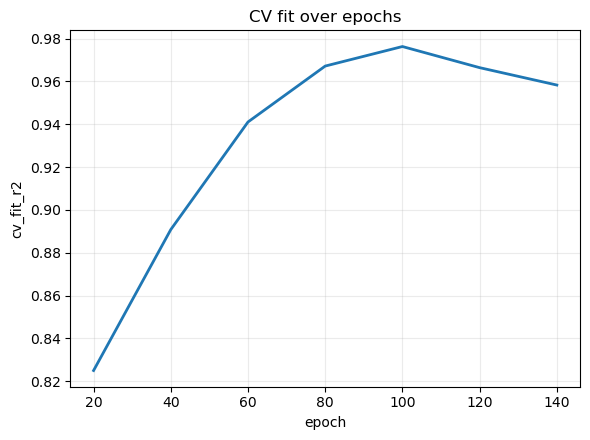

best cv_fit_r2= 0.9763090539339483 at epoch 100


In [7]:
# CV-fit over epochs.
run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)

epochs = np.asarray(stats['epoch'], dtype=int)
cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)
mask_cv = np.isfinite(cv_fit_r2)

fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(epochs[mask_cv], cv_fit_r2[mask_cv], '-', linewidth=2.0, color='tab:blue')
ax.set_xlabel('epoch')
ax.set_ylabel('cv_fit_r2')
ax.grid(alpha=0.25)
ax.set_title('CV fit over epochs')
plt.tight_layout()
plt.show()

best_i = int(np.nanargmax(cv_fit_r2))
print('best cv_fit_r2=', float(cv_fit_r2[best_i]), 'at epoch', int(epochs[best_i]))


In [8]:
# Load model from the saved best CV-fit checkpoint.
output_root = Path(cfg_cv_transformer.output_root)
selection = json.loads((output_root / 'cv_transformer_best_cv_selection.json').read_text())

run_dir = output_root / selection['run_name']
cfg_dict = json.loads((run_dir / 'config.json').read_text())
cfg_loaded = ExperimentConfig(**cfg_dict)

device = cfg_loaded.device

all_sims = load_dataset(cfg_loaded.dataset_path)
val_data = all_sims[cfg_loaded.train_count:cfg_loaded.train_count + cfg_loaded.val_count]
test_data = all_sims[cfg_loaded.train_count + cfg_loaded.val_count:]

init_frames = [val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)]
init_graph = build_graph(input_graphs=init_frames).to(device)

model = create_model(
    model_type=cfg_loaded.model_type,
    init_graph=init_graph,
    pos_dim=cfg_loaded.pos_dim,
    hidden_size=cfg_loaded.hidden_size,
    n_layers=cfg_loaded.n_layers,
    extras=cfg_loaded.model_extras,
).to(device)

best_ckpt = Path(selection['saved_checkpoint_path'])
model.load_checkpoint(str(best_ckpt))

model.eval()
if hasattr(model, 'freeze_normalizers'):
    model.freeze_normalizers = True
for p in model.parameters():
    p.requires_grad = False
model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

print('Loaded model:', cfg_loaded.model_type, 'device=', device)
print('Run dir:', run_dir)
print('Loaded best CV checkpoint:', best_ckpt)
print('best cv_fit_r2:', float(selection['best_cv_fit_r2']), 'epoch:', int(selection['best_cv_epoch']))
print('effective token sizes:', cfg_loaded.model_extras['token_sizes'])
print('validation sims:', len(val_data), '| test sims:', len(test_data))



Loaded model: cv_transformer device= cuda
Run dir: ../results/cv_transformer_single
Loaded best CV checkpoint: ../results/cv_transformer_best_cv_checkpoint.pt
best cv_fit_r2: 0.9763090539339483 epoch: 100
effective num CVs (CV): 4
validation sims: 20 | test sims: 77


In [9]:
# Extract trajectory-level CV summaries and final p-ratio for VAL and TEST.
def extract_cv_summary(sims, split_name):
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            n_local = len(sim) - 1
            final_pr = float(calc_p_ratio_box(sim, -1))
            cv_values = []
            for t in range(cfg_loaded.history, n_local):
                frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
                if t > 0:
                    prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                    cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                    frames[-1].vel_state = cur_pos - prev_pos
                input_graph = build_graph(frames).to(device)
                cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
                cv_values.append(np.asarray(cv, dtype=float).reshape(-1))

            cv_mean = np.mean(np.stack(cv_values, axis=0), axis=0)
            row = {
                'split': split_name,
                'sim_idx': sim_idx,
                'num_frames_used': len(cv_values),
                'final_p_ratio': final_pr,
            }
            for i, value in enumerate(cv_mean, start=1):
                row[f'cv_{i}'] = float(value)
            rows.append(row)
    return pd.DataFrame(rows).sort_values('sim_idx').reset_index(drop=True)


def extract_cv_frames(sims, split_name):
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            n_local = len(sim) - 1
            for t in range(cfg_loaded.history, n_local):
                frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
                if t > 0:
                    prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                    cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                    frames[-1].vel_state = cur_pos - prev_pos
                input_graph = build_graph(frames).to(device)
                cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
                row = {'split': split_name, 'sim_idx': sim_idx, 't': int(t)}
                for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1), start=1):
                    row[f'cv_{i}'] = float(value)
                rows.append(row)
    return pd.DataFrame(rows)


def fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    coeff = np.polyfit(x, y, deg=1)
    y_hat = coeff[0] * x + coeff[1]
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return float(1.0 - ss_res / ss_tot)


def cv_pratio_table(df, split_name):
    rows = []
    cv_cols = [c for c in df.columns if c.startswith('cv_')]
    y = df['final_p_ratio'].to_numpy(dtype=float)
    for col in cv_cols:
        x = df[col].to_numpy(dtype=float)
        rows.append({
            'split': split_name,
            'cv': col,
            'pearson_r': float(np.corrcoef(x, y)[0, 1]),
            'spearman_r': float(df[col].corr(df['final_p_ratio'], method='spearman')),
            'fit_r2': fit_r2(x, y),
        })
    out = pd.DataFrame(rows)
    out['abs_pearson_r'] = out['pearson_r'].abs()
    return out.sort_values('abs_pearson_r', ascending=False).reset_index(drop=True)


df_val = extract_cv_summary(val_data, 'val')
df_test = extract_cv_summary(test_data, 'test')

val_cv_table = cv_pratio_table(df_val, 'val')
test_cv_table = cv_pratio_table(df_test, 'test')

best_cv_col = str(val_cv_table.iloc[0]['cv'])
best_cv_idx = int(best_cv_col.split('_')[1]) - 1

print('best CV on val:', best_cv_col, '(index:', best_cv_idx, ')')
print(val_cv_table[['cv', 'pearson_r', 'spearman_r', 'fit_r2']])


best CV on val: cv_2 (index: 1 )
     cv  pearson_r  spearman_r    fit_r2
0  cv_2   0.988084    0.992481  0.976309
1  cv_3  -0.952527   -0.980451  0.907308
2  cv_4   0.904841    0.938346  0.818737
3  cv_1   0.872682    0.956391  0.761573


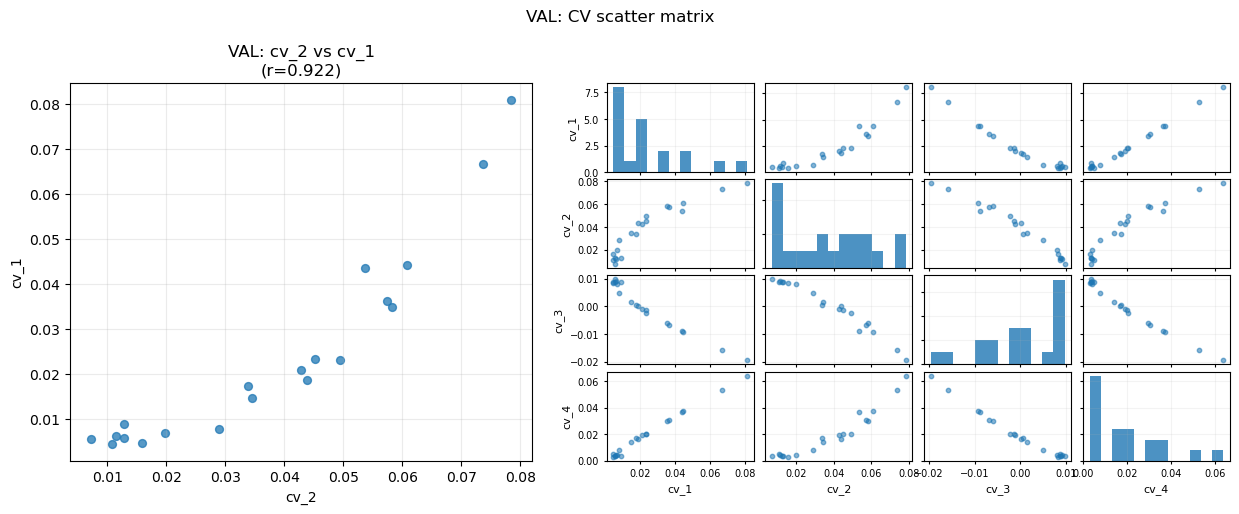

saved: ../results/cv_transformer_single/cv_transformer_val_all_cv_vs_pratio.csv
saved: ../results/cv_transformer_single/cv_transformer_val_cv_matrix_and_best_worst.png


In [10]:
# Plot best-vs-worst CV scatter and a full CV scatter matrix on VAL.
worst_cv_col = str(val_cv_table.iloc[-1]['cv'])
cv_cols = [c for c in df_val.columns if c.startswith('cv_')]

fig = plt.figure(figsize=(12.5, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.35])

ax0 = fig.add_subplot(gs[0, 0])
r_bw = float(df_val[best_cv_col].corr(df_val[worst_cv_col], method='pearson'))
ax0.scatter(df_val[best_cv_col], df_val[worst_cv_col], s=32, alpha=0.75)
ax0.set_title(f"VAL: {best_cv_col} vs {worst_cv_col}\n(r={r_bw:.3f})")
ax0.set_xlabel(best_cv_col)
ax0.set_ylabel(worst_cv_col)
ax0.grid(alpha=0.25)

n_cv = len(cv_cols)
subgs = gs[0, 1].subgridspec(n_cv, n_cv, wspace=0.08, hspace=0.08)
for i, row_cv in enumerate(cv_cols):
    for j, col_cv in enumerate(cv_cols):
        ax = fig.add_subplot(subgs[i, j])
        if i == j:
            ax.hist(df_val[col_cv].to_numpy(dtype=float), bins=12, alpha=0.8, color='tab:blue')
        else:
            ax.scatter(df_val[col_cv], df_val[row_cv], s=10, alpha=0.55)
        if i == n_cv - 1:
            ax.set_xlabel(col_cv, fontsize=8)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(row_cv, fontsize=8)
        else:
            ax.set_yticklabels([])
        ax.tick_params(axis='both', labelsize=7, length=2)
        ax.grid(alpha=0.15)

fig.suptitle('VAL: CV scatter matrix', y=0.98)
fig.tight_layout()

val_table_csv = run_dir / 'cv_transformer_val_all_cv_vs_pratio.csv'
val_cv_table.to_csv(val_table_csv, index=False)
all_cv_png = run_dir / 'cv_transformer_val_cv_matrix_and_best_worst.png'
fig.savefig(all_cv_png, dpi=180, bbox_inches='tight')
plt.show()

print('saved:', val_table_csv)
print('saved:', all_cv_png)


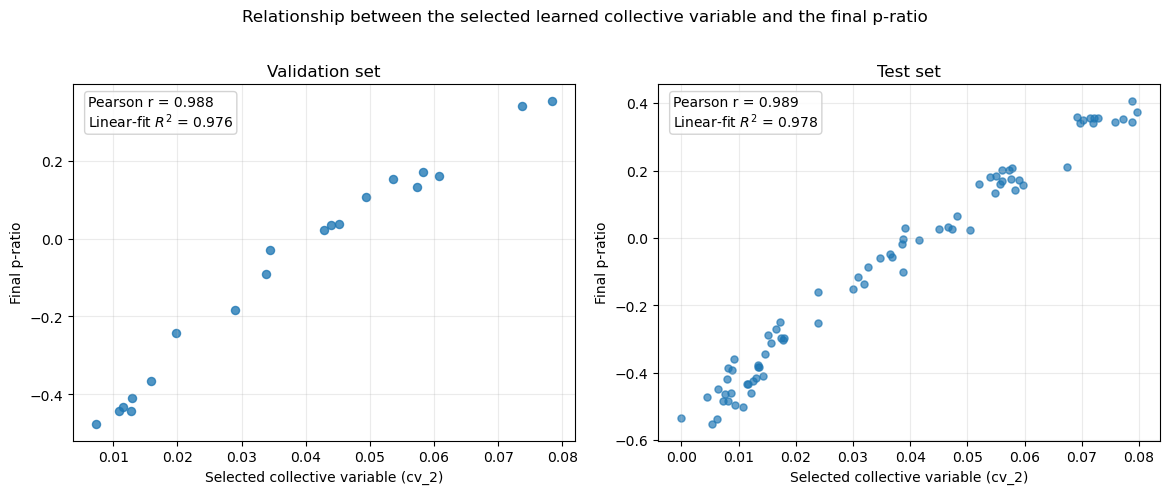

best checkpoint epoch: 100
saved: ../results/cv_transformer_single/cv_transformer_val_best_cv_vs_pratio.csv
saved: ../results/cv_transformer_single/cv_transformer_test_best_cv_vs_pratio.csv
saved: ../results/cv_transformer_single/cv_transformer_test_all_cv_vs_pratio.csv
saved: ../results/cv_transformer_single/cv_transformer_best_cv_val_test_scatter.png


In [11]:
# Report-style scatter of the selected CV against final p-ratio on VAL and TEST.
x_val = df_val[best_cv_col].to_numpy(dtype=float)
y_val = df_val['final_p_ratio'].to_numpy(dtype=float)
r_val = float(np.corrcoef(x_val, y_val)[0, 1])
r2_val = fit_r2(x_val, y_val)

x_test = df_test[best_cv_col].to_numpy(dtype=float)
y_test = df_test['final_p_ratio'].to_numpy(dtype=float)
r_test = float(np.corrcoef(x_test, y_test)[0, 1])
r2_test = fit_r2(x_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8))

axes[0].scatter(x_val, y_val, s=34, alpha=0.78)
axes[0].set_title('Validation set')
axes[0].set_xlabel(f'Selected collective variable ({best_cv_col})')
axes[0].set_ylabel('Final p-ratio')
axes[0].text(
    0.03, 0.97,
    f'Pearson r = {r_val:.3f}\nLinear-fit $R^2$ = {r2_val:.3f}',
    transform=axes[0].transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'),
)
axes[0].grid(alpha=0.25)

axes[1].scatter(x_test, y_test, s=26, alpha=0.68)
axes[1].set_title('Test set')
axes[1].set_xlabel(f'Selected collective variable ({best_cv_col})')
axes[1].set_ylabel('Final p-ratio')
axes[1].text(
    0.03, 0.97,
    f'Pearson r = {r_test:.3f}\nLinear-fit $R^2$ = {r2_test:.3f}',
    transform=axes[1].transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'),
)
axes[1].grid(alpha=0.25)

fig.suptitle(
    'Relationship between the selected learned collective variable and the final p-ratio',
    y=1.02,
)
fig.tight_layout()

val_csv = run_dir / 'cv_transformer_val_best_cv_vs_pratio.csv'
test_csv = run_dir / 'cv_transformer_test_best_cv_vs_pratio.csv'
test_table_csv = run_dir / 'cv_transformer_test_all_cv_vs_pratio.csv'
plot_png = run_dir / 'cv_transformer_best_cv_val_test_scatter.png'

df_val[['sim_idx', best_cv_col, 'final_p_ratio']].to_csv(val_csv, index=False)
df_test[['sim_idx', best_cv_col, 'final_p_ratio']].to_csv(test_csv, index=False)
test_cv_table.to_csv(test_table_csv, index=False)
fig.savefig(plot_png, dpi=180, bbox_inches='tight')

plt.show()

print('best checkpoint epoch:', int(selection['best_cv_epoch']))
print('saved:', val_csv)
print('saved:', test_csv)
print('saved:', test_table_csv)
print('saved:', plot_png)


In [ ]:
# Test-set Hessian check: selected best CV against lambda5.
hessian_rows = collect_cv_lambda5_points(
    model=model,
    sims=test_sims,
    history=cfg_loaded.history,
    pos_dim=cfg_loaded.pos_dim,
    device=device,
    cv_index=best_cv_idx,
)
hessian_df = pd.DataFrame(hessian_rows)
hessian_df = hessian_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['cv', 'lambda5']).reset_index(drop=True)

x = hessian_df['cv'].to_numpy(dtype=float)
y = hessian_df['lambda5'].to_numpy(dtype=float)
pearson_r = float(np.corrcoef(x, y)[0, 1])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(x, y, s=14, alpha=0.45)
ax.set_xlabel(f'Selected collective variable ({best_cv_col})')
ax.set_ylabel('Hessian slow mode $\lambda_5$')
ax.set_title('Test set: selected CV against $\lambda_5$')
ax.grid(alpha=0.2)
ax.text(0.03, 0.97, f'Pearson r = {pearson_r:.3f}\npoints = {len(hessian_df)}', transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='0.8'))
plt.tight_layout()
plt.show()

hessian_df.head()
